In [1]:
import pandas as pd  # Manipulação de dados
import matplotlib.pyplot as plt # Visualização de dados
import os
os.getcwd()


'c:\\Users\\ferna\\rj-temperature-analysis\\results'

* Carregando Dados

In [2]:
tempo_df = pd.read_csv('../data/temperatura-RJ.csv', skiprows=3
#,index_col='time' - outra forma de definir a coluna de índice
# parse_dates =  True - outra forma de converter a coluna para datetime
)
tempo_df

,time,temperature_2m_mean (°C)
0,1979-01-01,26.9
1,1979-01-02,26.0
2,1979-01-03,26.4
3,1979-01-04,24.2
4,1979-01-05,23.2
...,...,...
16978,2025-06-26,20.6
16979,2025-06-27,22.1
16980,2025-06-28,22.7
16981,2025-06-29,24.1


* Definindo o index

In [3]:
tempo_df.set_index('time', inplace=True)
tempo_df


,temperature_2m_mean (°C)
time,
1979-01-01,26.9
1979-01-02,26.0
1979-01-03,26.4
1979-01-04,24.2
1979-01-05,23.2
...,...
2025-06-26,20.6
2025-06-27,22.1
2025-06-28,22.7


* Conertendo para date_time

In [4]:
tempo_df.index = pd.to_datetime(tempo_df.index)
tempo_df.index = tempo_df.index.date
tempo_df

,temperature_2m_mean (°C)
1979-01-01,26.9
1979-01-02,26.0
1979-01-03,26.4
1979-01-04,24.2
1979-01-05,23.2
...,...
2025-06-26,20.6
2025-06-27,22.1
2025-06-28,22.7
2025-06-29,24.1


* Conferindo formatos

In [5]:
tempo_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16983 entries, 1979-01-01 to 2025-06-30
Data columns (total 1 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   temperature_2m_mean (°C)  16983 non-null  float64
dtypes: float64(1)
memory usage: 265.4+ KB


* Verificando valores nulos 

In [6]:
print("Valores nulos em coluna temperatura: ")
(tempo_df.isna() | tempo_df.isnull() | tempo_df == "").sum()

Valores nulos em coluna temperatura: 


temperature_2m_mean (°C)    0
dtype: int64

* Estatísticas Básicas

In [7]:
print("Conferindo estatísticas descritivas: ")
tempo_df.describe()

Conferindo estatísticas descritivas: 


,temperature_2m_mean (°C)
count,16983.000000
mean,23.799335
std,2.710368
min,15.300000
25%,21.800000
50%,23.800000
75%,25.900000
max,31.300000


* Verificando Outliers

<Axes: >

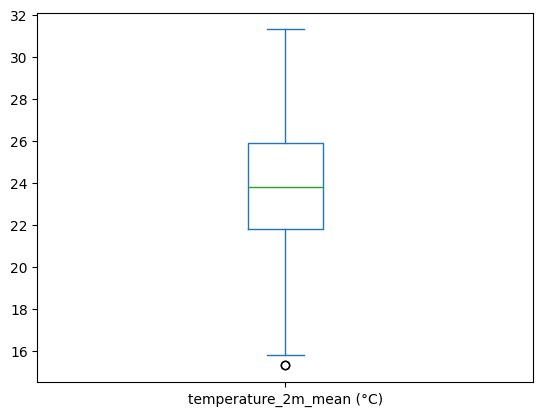

In [8]:
tempo_df.plot(kind='box')

* Verificação de Dias mais frios e Dias mais quentes

In [9]:
coldest_day = tempo_df['temperature_2m_mean (°C)'].idxmin()
print(f"A menor temperatura registrada foi em: {coldest_day}")


A menor temperatura registrada foi em: 1988-07-13


In [10]:
hottest_day = tempo_df['temperature_2m_mean (°C)'].idxmax()
print(f"A menor temperatura registrada foi em: {hottest_day}")

A menor temperatura registrada foi em: 2023-11-18


* Médias Mensais

<Axes: >

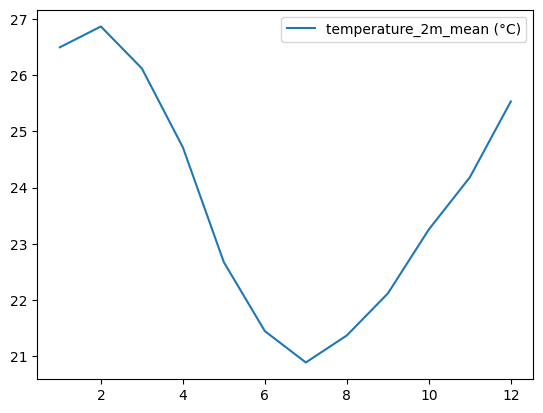

In [11]:
tempo_df.index = pd.to_datetime(tempo_df.index)

monthly_avg = tempo_df.groupby(tempo_df.index.month).mean()

monthly_avg.plot()


<Axes: >

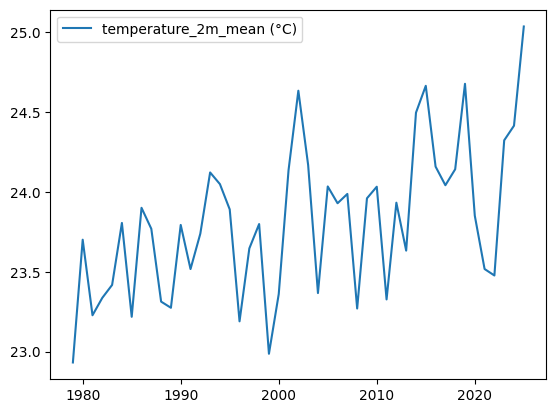

In [12]:
yearly_avg = tempo_df.groupby(tempo_df.index.year).mean()

yearly_avg.plot()

In [13]:

hottest_year = yearly_avg.drop(2025).idxmax() #Dados de 2025 incompletos
coldest_year = yearly_avg.idxmin()

print(f"O ano mais quente foi: {hottest_year}")
print(f"O ano mais frio foi: {coldest_year}")


O ano mais quente foi: temperature_2m_mean (°C)    2019
dtype: int32
O ano mais frio foi: temperature_2m_mean (°C)    1979
dtype: int32


* Análise Gráfica

In [14]:
# Estilização de gráficos com Matplotlib
plt.style.use('dark_background')

In [15]:
annual_data = yearly_avg.drop(2025)
annual_data.head(5)

,temperature_2m_mean (°C)
1979,22.932055
1980,23.700820
1981,23.227671
1982,23.336712
1983,23.417534


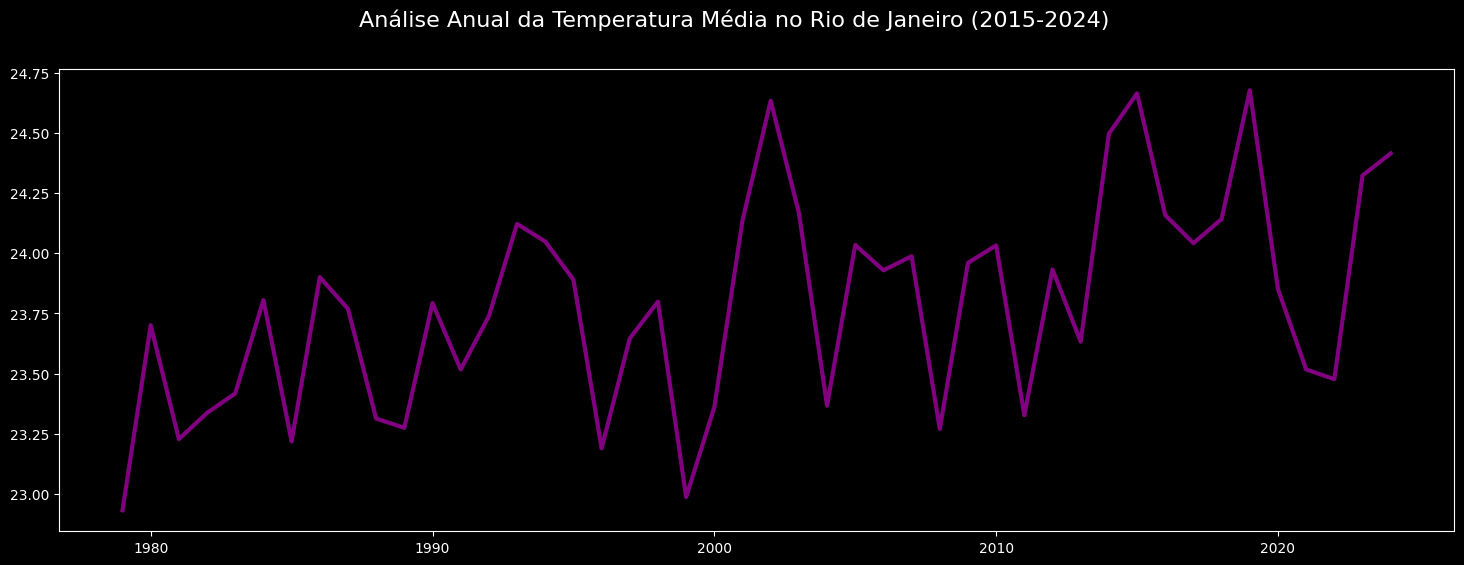

In [16]:
# Definindo o tamanho da figura
fig, ax = plt.subplots(figsize=(18, 6))

#Define o título da figura
fig.suptitle('Análise Anual da Temperatura Média no Rio de Janeiro (2015-2024)', fontsize=16)

# plotagem da linha com customização de cor e largura
ax.plot(annual_data, color='purple', lw=3)

# Salvando o gráfico 
fig.savefig('../results/temperatura_anual_rj.png')

* Exportação de dados

In [17]:
# Exportando os dados anuais para Excel
annual_data.to_excel('../results/temperatura_anual_rj_dados.xlsx')